# Telco Customer Churn - EDA & Preprocessing

**Milestone 2**: EDA graphs + final train/test datasets ready for modeling.

Pipeline: load data -> clean -> handle missing values -> outlier check -> EDA -> encode -> split -> scale -> save.


In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
# Load and inspect
df = pd.read_csv('../data/Telco-Customer-Churn.csv')
print(df.shape)
print(df.dtypes)
df.head()


(7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
#fixtotalcharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df.isnull().sum())


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [4]:
#fillmissingvalues
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())


In [5]:
#dropduplicates and customerID
df = df.drop_duplicates(keep='first').reset_index(drop=True)
df = df.drop(columns=['customerID'])
print(df.shape)


(7043, 20)


### Outlier check
Using IQR on tenure, MonthlyCharges, TotalCharges. Flagged points reflect real long-tenure/high-spend customers rather than data entry errors, so nothing is removed - just documented here.

In [6]:
#outlier check (IQR method) on key numeric columns
num_cols_check = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in num_cols_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col}: {n_outliers} outliers outside [{lower:.2f}, {upper:.2f}]")

# these are genuine business values (long tenure / high bills), not data errors, so we keep them as-is


tenure: 0 outliers outside [-60.00, 124.00]
MonthlyCharges: 0 outliers outside [-46.02, 171.38]


TotalCharges: 0 outliers outside [-4674.34, 8863.16]


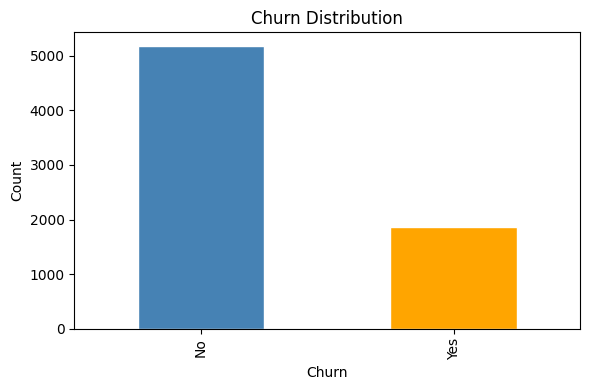

In [7]:
#Churndistribution
fig, ax = plt.subplots(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', ax=ax, color=['steelblue','orange'], edgecolor='white')
ax.set_title('Churn Distribution')
ax.set_xlabel('Churn')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../results/EDA_graphs/churn_distribution.png')
plt.show()


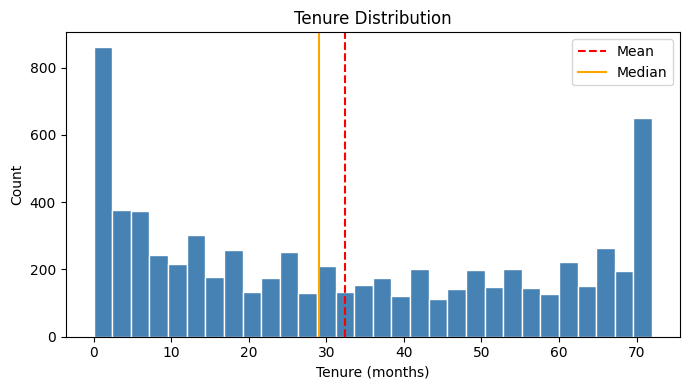

In [8]:
#tenure histogram
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(df['tenure'], bins=30, color='steelblue', edgecolor='white')
ax.axvline(df['tenure'].mean(), color='red', linestyle='--', label='Mean')
ax.axvline(df['tenure'].median(), color='orange', linestyle='-', label='Median')
ax.set_title('Tenure Distribution')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../results/EDA_graphs/tenure_distribution.png')
plt.show()


/tmp/ipykernel_570/2891386428.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax, palette=['steelblue','orange'])


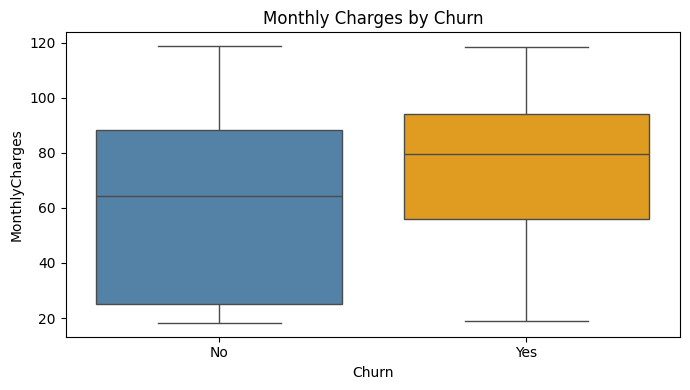

In [9]:
#monthlycharges by churn
fig, ax = plt.subplots(figsize=(7,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax, palette=['steelblue','orange'])
ax.set_title('Monthly Charges by Churn')
plt.tight_layout()
plt.savefig('../results/EDA_graphs/monthly_charges_churn.png')
plt.show()


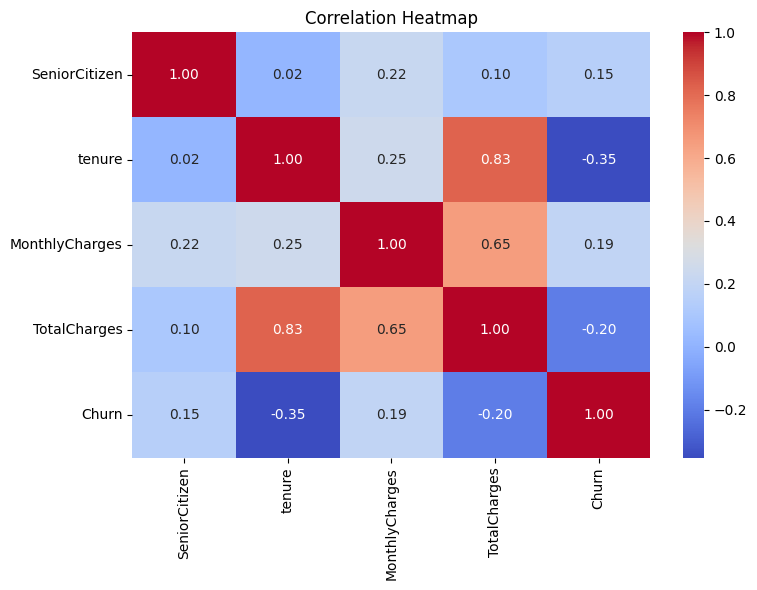

In [10]:
#Correlation heatmap
fig, ax = plt.subplots(figsize=(8,6))
df_temp = df.copy()
df_temp['Churn'] = df_temp['Churn'].map({'Yes':1,'No':0})
numeric_df = df_temp[['SeniorCitizen','tenure','MonthlyCharges','TotalCharges','Churn']]
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../results/EDA_graphs/correlation_heatmap.png')
plt.show()


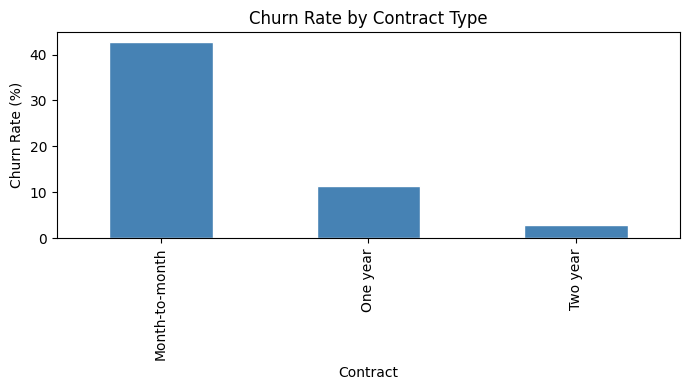

In [11]:
#Churn by Contract
fig, ax = plt.subplots(figsize=(7,4))
df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()*100).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Churn Rate by Contract Type')
ax.set_xlabel('Contract')
ax.set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('../results/EDA_graphs/churn_by_contract.png')
plt.show()


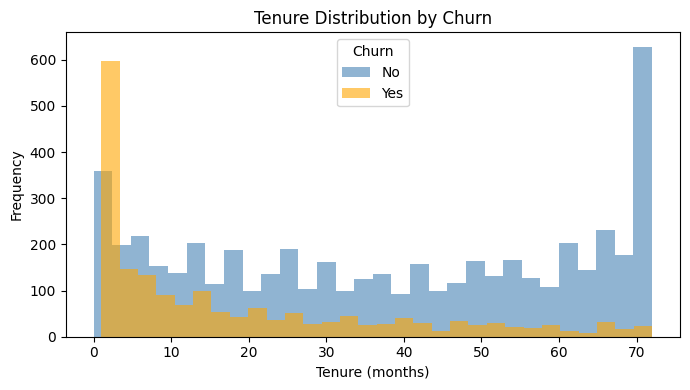

In [12]:
# Tenure by Churn
fig, ax = plt.subplots(figsize=(7,4))
for label, color in zip(['No','Yes'], ['steelblue','orange']):
    df[df['Churn']==label]['tenure'].plot(kind='hist', bins=30, alpha=0.6, ax=ax, color=color, label=label)
ax.set_title('Tenure Distribution by Churn')
ax.set_xlabel('Tenure (months)')
ax.legend(title='Churn')
plt.tight_layout()
plt.savefig('../results/EDA_graphs/tenure_by_churn.png')
plt.show()


/tmp/ipykernel_570/1877796858.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=ax, palette=['steelblue','orange'])


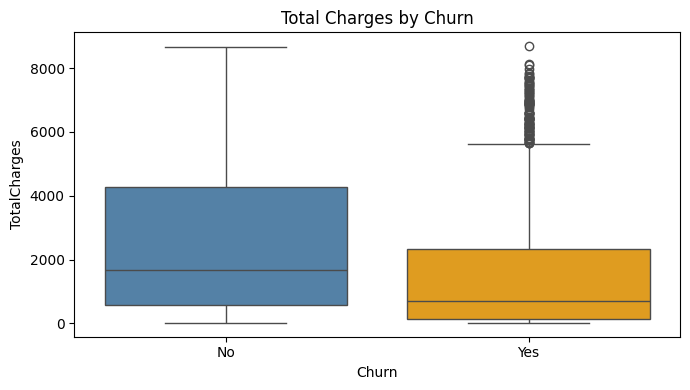

In [13]:
#TotalCharges by Churn
fig, ax = plt.subplots(figsize=(7,4))
sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=ax, palette=['steelblue','orange'])
ax.set_title('Total Charges by Churn')
plt.tight_layout()
plt.savefig('../results/EDA_graphs/totalcharges_churn.png')
plt.show()


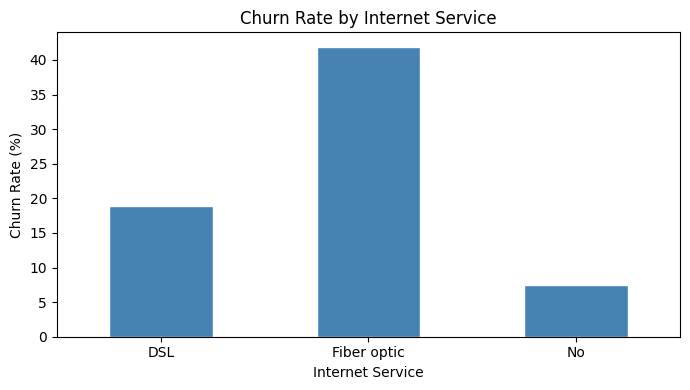

In [14]:
#Churn by Internet Service
fig, ax = plt.subplots(figsize=(7,4))
df.groupby('InternetService')['Churn'].apply(lambda x: (x=='Yes').mean()*100).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Churn Rate by Internet Service')
ax.set_xlabel('Internet Service')
ax.set_ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/EDA_graphs/churn_by_internet.png')
plt.show()


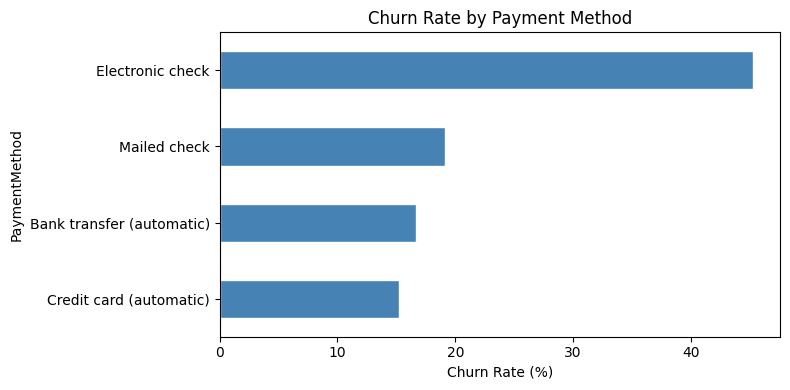

In [15]:
#Churn by Payment Method
fig, ax = plt.subplots(figsize=(8,4))
df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x=='Yes').mean()*100).sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Churn Rate by Payment Method')
ax.set_xlabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('../results/EDA_graphs/churn_by_payment.png')
plt.show()


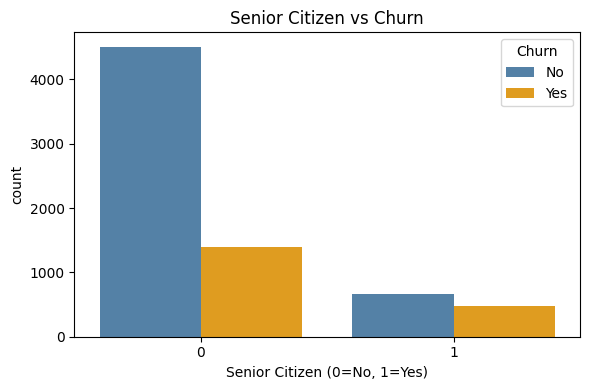

In [16]:
# Senior Citizen vs Churn
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', ax=ax, palette=['steelblue','orange'])
ax.set_title('Senior Citizen vs Churn')
ax.set_xlabel('Senior Citizen (0=No, 1=Yes)')
plt.tight_layout()
plt.savefig('../results/EDA_graphs/senior_citizen_churn.png')
plt.show()


In [17]:
#Encode target and features
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes':1, 'No':0})

X['gender'] = X['gender'].map({'Male':1, 'Female':0})
for col in ['Partner','Dependents','PhoneService','PaperlessBilling']:
    X[col] = X[col].map({'Yes':1, 'No':0})

X['Contract'] = X['Contract'].map({'Month-to-month':0, 'One year':1, 'Two year':2})

nominal_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
                'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaymentMethod']
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True, dtype=int)

print(X.shape)


(7043, 29)


In [18]:
#Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"Churn rate train: {y_train.mean()*100:.2f}%")
print(f"Churn rate test: {y_test.mean()*100:.2f}%")


X_train: (5634, 29)
X_test: (1409, 29)
Churn rate train: 26.54%
Churn rate test: 26.54%


In [19]:
#Scale numeric columns
numeric_cols = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


In [20]:
#Save final datasets
X_train.to_csv('../results/final_data/X_train.csv', index=False)
X_test.to_csv('../results/final_data/X_test.csv', index=False)
y_train.to_csv('../results/final_data/y_train.csv', index=False)
y_test.to_csv('../results/final_data/y_test.csv', index=False)
print("Done")


Done
